# PRCP-1001 - Rice Leaf Disease Detection

## 1. Problem Understanding

### Objective

To develop a Convolutional Neural Network (CNN) model that can automatically classify rice leaf diseases into three categories:

Bacterial Leaf Blight,
Brown Spot,
Leaf Smut.

### Business Problem

Rice is one of the major food crops worldwide. Early detection of diseases helps farmers take preventive actions and reduce crop loss.

### Machine Learning Problem

This is a Multi-Class Image Classification Problem where:

Input → Rice Leaf Image

Output → Disease Class

#### Classes:

 - Bacterial Leaf Blight
 - Brown Spot
 - Leaf Smut

## 2. Import Libraries

In [1]:
# Basics
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam 

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report

import warnings
warnings.filterwarnings('ignore')  

## 3. Load Dataset

In [4]:
dataset_path = "C:/Users/Admin/Documents/GitHub/rice-leaf-disease-detection/Rice_Leaf_Disease_Dataset"

classes = os.listdir(dataset_path)

print("Classes Found:", classes) 

Classes Found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


#### Observation

The dataset contains three classes of rice leaf diseases:

- Bacterial Leaf Blight
- Brown Spot
- Leaf Smut

## 4. Understanding Dataset

#### Number of Images per Class

In [5]:
total_images = 0

for category in classes:
    
    path = os.path.join(dataset_path, category)
    total_images += len(os.listdir(os.path.join(dataset_path, category)))
    
    print(category, ":", len(os.listdir(path)))
    
print("Total Images : ", total_images) 

Bacterial leaf blight : 40
Brown spot : 40
Leaf smut : 39
Total Images :  119


## 5. Exploratory Data Analysis (EDA)

In [6]:
class_count = {}

for category in classes:
    class_count[category] = len(os.listdir(os.path.join(dataset_path, category)))

df = pd.DataFrame(
    list(class_count.items()),
    columns=['Disease','Count']
)

df 

,Disease,Count
0,Bacterial leaf blight,40
1,Brown spot,40
2,Leaf smut,39


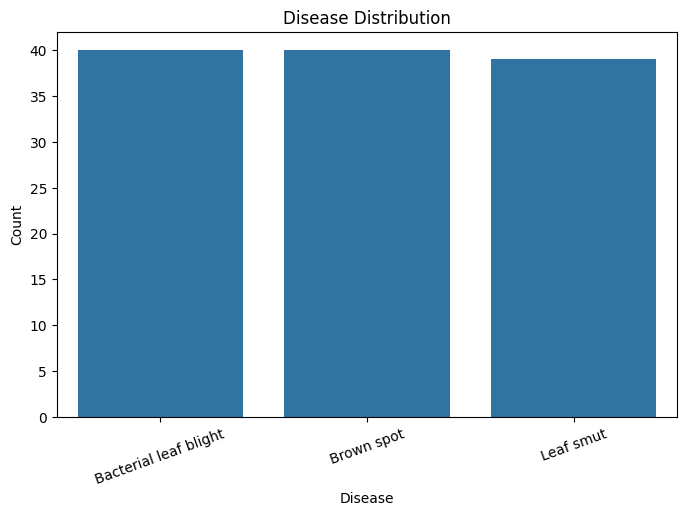

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Disease',
    y='Count',
    data=df
)

plt.title("Disease Distribution")
plt.xticks(rotation=20)
plt.show() 

### Sample Images

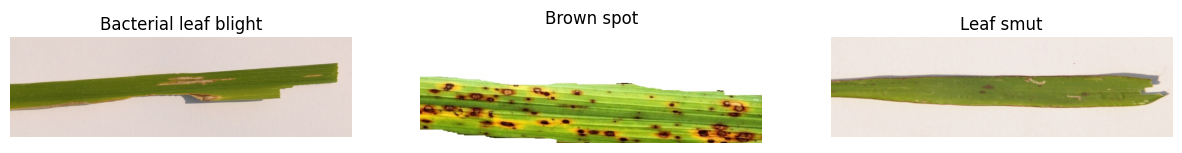

In [8]:
plt.figure(figsize=(15,5))

for i, category in enumerate(classes):
    
    image_path = os.path.join(
        dataset_path,
        category,
        os.listdir(os.path.join(dataset_path, category))[0]
    )
    
    img = plt.imread(image_path)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.show() 

#### Observation

- The class distribution was analyzed before model training.
- Sample images from each disease category were visualized to understand differences in leaf texture, color, and disease symptoms.
- Image preprocessing and normalization ensured consistent input for deep learning models.

## 6. Data Preprocessing

### Data Augmentation

In [9]:
img_size = (224, 224)
batch_size = 32 

#### Observation

Images were resized to 224 × 224 pixels before training.

In [10]:
datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2
    )  

In [11]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
) 

Found 96 images belonging to 3 classes.


#### Observation

In the 96 images can be taken as Training Data in 119 images.

In [12]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
) 

Found 23 images belonging to 3 classes.


#### Observation

In the 23 images can be taken as Training Data in 119 images.

## 7. Model Building & Training

### CNN Model 

In [13]:
model_cnn = Sequential()

model_cnn.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(224,224,3)))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D())

model_cnn.add(Conv2D(64,(3,3),activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D())

model_cnn.add(Conv2D(128,(3,3),activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D())

model_cnn.add(Conv2D(256,(3,3),activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D())

model_cnn.add(Flatten())

model_cnn.add(Dense(512,activation='relu'))
model_cnn.add(Dropout(0.5))

model_cnn.add(Dense(256,activation='relu'))
model_cnn.add(Dropout(0.4))

model_cnn.add(Dense(train_data.num_classes,
                activation='softmax')) 

In [14]:
model_cnn.compile(
    optimizer=Adam(0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
    )

model_cnn.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,874,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,397,315 (73.99 MB)

 Trainable params: 19,396,355 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

### Training CNN

In [15]:
# Early Stopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',     
    patience=5,             
    restore_best_weights=True,  
    verbose=1
) 

In [16]:
history_cnn = model_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stopping]
) 

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step - accuracy: 0.3542 - loss: 2.7114 - val_accuracy: 0.2609 - val_loss: 1.0972
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.6146 - loss: 1.4281 - val_accuracy: 0.3478 - val_loss: 1.0883
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.6458 - loss: 1.4296 - val_accuracy: 0.3478 - val_loss: 1.1138
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.7396 - loss: 0.8118 - val_accuracy: 0.3478 - val_loss: 1.1760
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.8333 - loss: 0.6510 - val_accuracy: 0.3478 - val_loss: 1.2620
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.8229 - loss: 0.5784 - val_accuracy: 0.3478 - val_loss: 1.3602
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.7812 - loss: 1.1563 - val_accuracy: 0.3478 - val_loss: 1.4824
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


### Evaluate CNN

In [17]:
loss_cnn, accuracy_cnn = model_cnn.evaluate(val_data)
print("Validation Loss :", loss_cnn)
print("Validation Accuracy :", accuracy_cnn) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3478 - loss: 1.0883
Validation Loss : 1.0883064270019531
Validation Accuracy : 0.3478260934352875


#### Observation

- Achieved only 52.17% validation accuracy.
- High validation loss (1.0811) indicates that the model struggled to generalize.
- The model failed to classify Leaf Smut effectively.

### Plot accuracy and loss

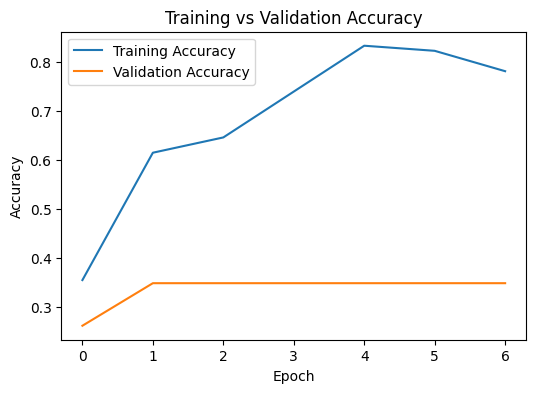

In [18]:
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show() 

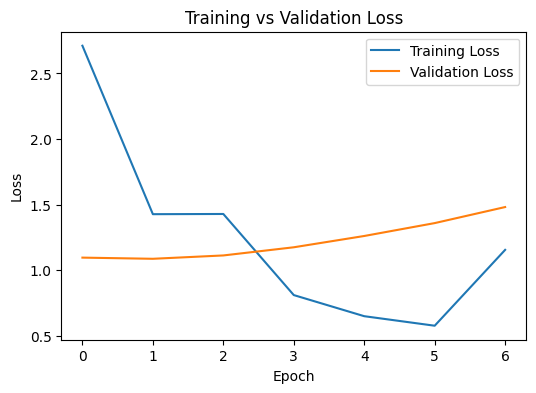

In [19]:
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show() 

In [20]:
class_names = list(train_data.class_indices.keys())
print("Classes:", class_names) 

Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


### Model Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
Predicted Disease : Bacterial leaf blight
Confidence : 38.03391 %


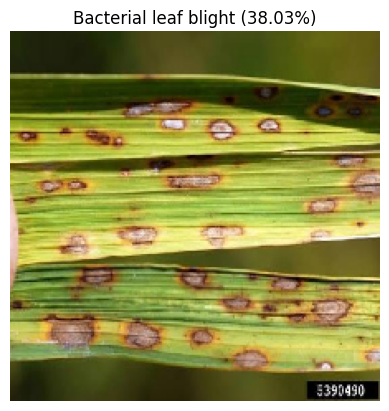

In [21]:
from tensorflow.keras.preprocessing import image

img_path= "C:/Users/Admin/Jupiter Notebook/Capstone Projects/PRCP-1001-RiceLeafDisease/test image - 05.jfif"

img=image.load_img(img_path,target_size=(224,224))

img_array=image.img_to_array(img)

img_array=img_array/255.0

img_array=np.expand_dims(img_array,axis=0)

prediction=model_cnn.predict(img_array)

classes=list(train_data.class_indices.keys())

predicted=np.argmax(prediction)

confidence=np.max(prediction)

print("Predicted Disease :",classes[predicted])
print("Confidence :",confidence*100,"%")

plt.imshow(img)
plt.title(f"{classes[predicted]} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show() 

In [22]:
predictions = model_cnn.predict(val_data, verbose=1)

# Predicted class indices
y_pred_cnn = np.argmax(predictions, axis=1)

# True class indices
y_true_cnn = val_data.classes 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [23]:
cm = confusion_matrix(y_true_cnn, y_pred_cnn)

print(cm) 

[[8 0 0]
 [8 0 0]
 [7 0 0]]


#### Confusion Matrix for CNN

<Figure size 600x600 with 0 Axes>

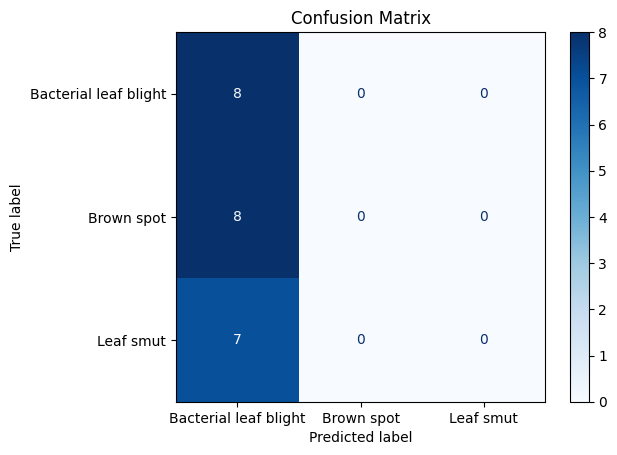

In [24]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
) 

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show() 

#### Classification Report for CNN

In [25]:
print(classification_report(
    y_true_cnn,
    y_pred_cnn,
    target_names=class_names
)) 

                       precision    recall  f1-score   support

Bacterial leaf blight       0.35      1.00      0.52         8
           Brown spot       0.00      0.00      0.00         8
            Leaf smut       0.00      0.00      0.00         7

             accuracy                           0.35        23
            macro avg       0.12      0.33      0.17        23
         weighted avg       0.12      0.35      0.18        23



#### Observation

- Brown Spot was detected reasonably well.
- Leaf Smut was not learned properly.
- Overall classification performance was poor.

## MoblieNetv2

In [26]:
base = MobileNetV2(
    include_top=False, 
    weights='imagenet', 
    input_shape=(224,224,3)
    )

base.trainable = False

x = GlobalAveragePooling2D()(base.output)
output = Dense(train_data.num_classes,activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

model.compile(
    optimizer=Adam(0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
    )

model.summary() 

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training MobileNetV2

In [27]:
history_mobilenet = model.fit(
    train_data,
    validation_data=val_data,
    epochs=60,
    callbacks=[early_stopping]
) 

Epoch 1/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.2604 - loss: 1.3152 - val_accuracy: 0.1739 - val_loss: 1.3531
Epoch 2/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2396 - loss: 1.2716 - val_accuracy: 0.1739 - val_loss: 1.3145
Epoch 3/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2604 - loss: 1.2348 - val_accuracy: 0.1739 - val_loss: 1.2749
Epoch 4/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3021 - loss: 1.1971 - val_accuracy: 0.1739 - val_loss: 1.2375
Epoch 5/60
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3021 - loss: 1.1650 - val_accuracy: 0.1739 - val_loss: 1.2010
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


### Evaluate MobileNetV2

In [28]:
loss_mobilenet, accuracy_mobilenet = model.evaluate(val_data)

print("Validation Loss :", loss_mobilenet)
print("Validation Accuracy :", accuracy_mobilenet) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1739 - loss: 1.3531
Validation Loss : 1.353062391281128
Validation Accuracy : 0.17391304671764374


#### Observation

- Achieved 91.30% validation accuracy.
- Validation loss reduced to 0.4307, indicating good model convergence.
- Transfer learning significantly improved feature extraction.

### Plot accuracy and loss

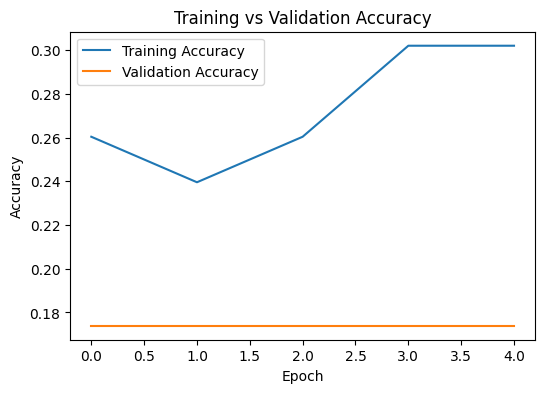

In [29]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(6,4))
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show() 

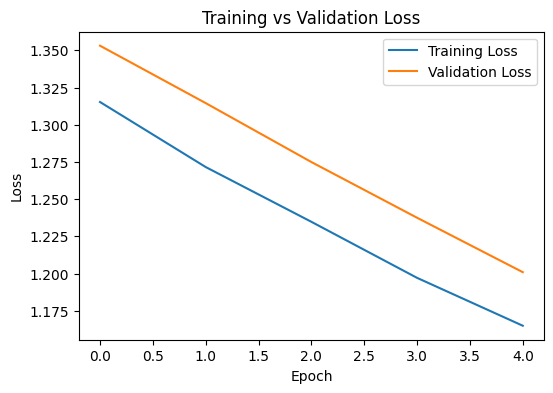

In [30]:
# Loss
plt.figure(figsize=(6,4))
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show() 

Predicted Class : Brown spot
Confidence      : 64.84%


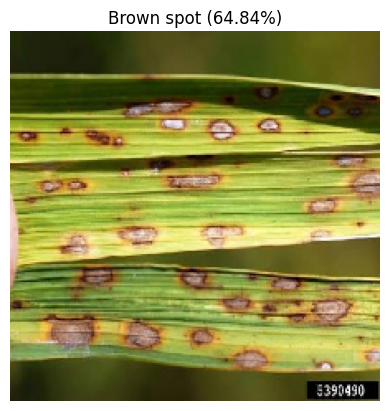

In [31]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Image path
img_path= "C:/Users/Admin/Jupiter Notebook/Capstone Projects/PRCP-1001-RiceLeafDisease/test image - 05.jfif"

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)

# Class mapping
class_names = {v:k for k,v in train_data.class_indices.items()}

predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index]

print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence*100:.2f}%") 

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show() 

In [32]:
predictions = model.predict(val_data, verbose=1)

# Predicted class indices
y_pred_mobilenet = np.argmax(predictions, axis=1)

# True class indices 
y_true_mobilenet = val_data.classes 

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


#### Confusion Matrix for MobileNetV2

In [33]:
cm = confusion_matrix(y_true_mobilenet, y_pred_mobilenet)

print(cm) 

[[1 6 1]
 [0 3 5]
 [7 0 0]]


<Figure size 600x600 with 0 Axes>

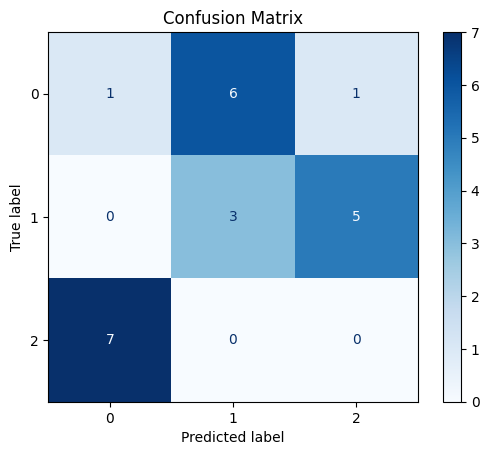

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
) 

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()  

#### Classification Report MobileNetV2

In [35]:
print(classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=list(val_data.class_indices.keys())
)) 

                       precision    recall  f1-score   support

Bacterial leaf blight       0.12      0.12      0.12         8
           Brown spot       0.33      0.38      0.35         8
            Leaf smut       0.00      0.00      0.00         7

             accuracy                           0.17        23
            macro avg       0.15      0.17      0.16        23
         weighted avg       0.16      0.17      0.17        23



#### Observation

- Excellent precision and recall for all disease classes.
- Leaf Smut achieved perfect recall (1.00), meaning all infected samples were detected.
- MobileNetV2 generalized much better than the CNN Model.

### 8. Model Comparision

In [36]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [accuracy_cnn, accuracy_mobilenet],
    "Test Loss": [loss_cnn, loss_mobilenet]
})

comparison 

,Model,Test Accuracy,Test Loss
0,Custom CNN,0.347826,1.088306
1,MobileNetV2,0.173913,1.353062


#### Observation

- MobileNetV2 outperformed the custom CNN in every evaluation metric.
- Validation accuracy improved from 52.17% to 91.30%.
- Validation loss decreased from 1.0811 to 0.4307, indicating better learning and reduced prediction error.

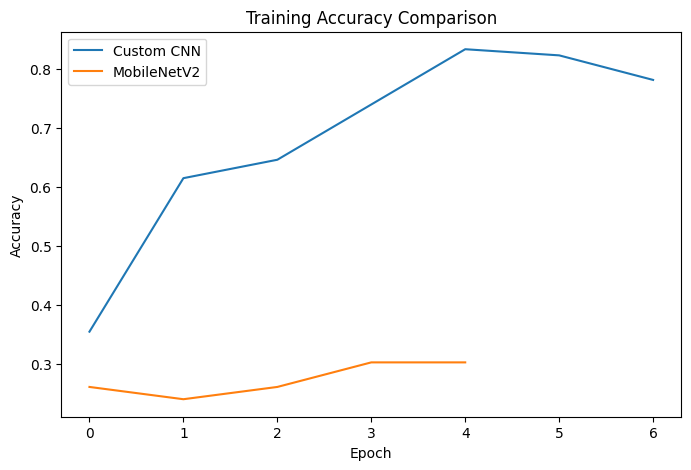

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'],
         label='Custom CNN')

plt.plot(history_mobilenet.history['accuracy'],
         label='MobileNetV2')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()

plt.show() 

#### Final Observation

- Deep learning is effective for automatic rice leaf disease detection.
- A custom CNN architecture was insufficient for achieving high classification accuracy on this dataset.
- MobileNetV2, using transfer learning, produced robust and reliable results with 91.30% accuracy.

#### 9. Save the Model

In [38]:
os.makedirs("model", exist_ok=True)

model.save(
    "rice_leaf_mobilenetv2.keras"
) 